In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

import torch
import torch.nn as nn
import torch.optim as optim

import xgboost as xgb
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from imblearn.over_sampling import SMOTE
import joblib

import warnings
warnings.filterwarnings('ignore')

%matplotlib inline
sns.set_style("whitegrid")

print("✓ Imports successful")

✓ Imports successful


In [2]:
print("="*60)
print("ADVERSARIAL TRAINING - DEFENSE MECHANISM")
print("="*60)

print("""
The Problem:
  - Our baseline model: 99.98% on clean data
  - Under FGSM attack: drops to 62.97%
  - Under C&W attack: drops to 60.32%
  - Model has never seen adversarial examples!

Adversarial Training Solution:
  
  Normal Training:
    Train on: Clean examples only
    Result:   Great on clean data, terrible on adversarial
  
  Adversarial Training:
    Train on: Mix of clean AND adversarial examples
    Result:   Robust to attacks, slight drop on clean data
  
Algorithm:
  1. Start with clean training data (X_train, y_train)
  2. Generate adversarial examples using FGSM/PGD
  3. Combine clean + adversarial into augmented dataset
  4. Train model on augmented data
  5. Model learns to be robust!

Expected Results:
  Clean accuracy:    99.98% → 96-97% (slight drop)
  FGSM accuracy:     62.97% → 85-88% (huge improvement!)
  PGD accuracy:      63.64% → 84-87%
  C&W accuracy:      60.32% → 80-84%

Why It Works:
  - Model sees adversarial examples during training
  - Learns robust features that survive perturbations
  - Decision boundaries become smoother
  - Most effective defense in research

Trade-off:
  - Slight accuracy drop on clean data
  - Much better robustness under attack
  - Worth it for security-critical applications!
""")

ADVERSARIAL TRAINING - DEFENSE MECHANISM

The Problem:
  - Our baseline model: 99.98% on clean data
  - Under FGSM attack: drops to 62.97%
  - Under C&W attack: drops to 60.32%
  - Model has never seen adversarial examples!

Adversarial Training Solution:

  Normal Training:
    Train on: Clean examples only
    Result:   Great on clean data, terrible on adversarial

  Adversarial Training:
    Train on: Mix of clean AND adversarial examples
    Result:   Robust to attacks, slight drop on clean data

Algorithm:
  1. Start with clean training data (X_train, y_train)
  2. Generate adversarial examples using FGSM/PGD
  3. Combine clean + adversarial into augmented dataset
  4. Train model on augmented data
  5. Model learns to be robust!

Expected Results:
  Clean accuracy:    99.98% → 96-97% (slight drop)
  FGSM accuracy:     62.97% → 85-88% (huge improvement!)
  PGD accuracy:      63.64% → 84-87%
  C&W accuracy:      60.32% → 80-84%

Why It Works:
  - Model sees adversarial examples dur

In [3]:
print("\n" + "="*60)
print("LOADING DATA AND MODELS")
print("="*60)

# Load clean training data
X_train = np.load('../data/processed/X_train.npy')
X_test = np.load('../data/processed/X_test.npy')
y_train = np.load('../data/processed/y_train.npy')
y_test = np.load('../data/processed/y_test.npy')

print(f"✓ Training set: {X_train.shape}")
print(f"✓ Test set: {X_test.shape}")

# Load baseline model for comparison
baseline_model = joblib.load('../models/base_classifier/xgboost_baseline.pkl')
baseline_metrics = joblib.load('../models/base_classifier/baseline_metrics.pkl')
baseline_accuracy = baseline_metrics['test_metrics']['accuracy']

print(f"✓ Baseline model accuracy: {baseline_accuracy:.4f}")

# Load surrogate model for generating adversarial examples
class SurrogateNet(nn.Module):
    def __init__(self, input_dim):
        super(SurrogateNet, self).__init__()
        self.fc1 = nn.Linear(input_dim, 128)
        self.dropout1 = nn.Dropout(0.3)
        self.fc2 = nn.Linear(128, 64)
        self.dropout2 = nn.Dropout(0.3)
        self.fc3 = nn.Linear(64, 32)
        self.dropout3 = nn.Dropout(0.2)
        self.fc4 = nn.Linear(32, 2)
        
    def forward(self, x):
        x = torch.relu(self.fc1(x))
        x = self.dropout1(x)
        x = torch.relu(self.fc2(x))
        x = self.dropout2(x)
        x = torch.relu(self.fc3(x))
        x = self.dropout3(x)
        x = self.fc4(x)
        return x

input_dim = X_train.shape[1]
surrogate_model = SurrogateNet(input_dim)
surrogate_model.load_state_dict(torch.load('../models/attacks/surrogate_model.pth'))
surrogate_model.eval()

print("✓ Surrogate model loaded")

# Load attack results for comparison
fgsm_results = joblib.load('../models/attacks/fgsm_results.pkl')
pgd_results = joblib.load('../models/attacks/pgd_results.pkl')
cw_results = joblib.load('../models/attacks/cw_results.pkl')

print(f"\n✓ Baseline under attacks:")
print(f"  FGSM: {fgsm_results['best_accuracy']:.4f}")
print(f"  PGD:  {pgd_results['best_config']['accuracy']:.4f}")
print(f"  C&W:  {cw_results['best_config']['accuracy']:.4f}")



LOADING DATA AND MODELS
✓ Training set: (831892, 41)
✓ Test set: (207974, 41)
✓ Baseline model accuracy: 0.9998
✓ Surrogate model loaded

✓ Baseline under attacks:
  FGSM: 0.6297
  PGD:  0.6364
  C&W:  0.6032


In [4]:
print("\n" + "="*60)
print("GENERATING ADVERSARIAL TRAINING DATA")
print("="*60)

def fgsm_attack(model, x, y, epsilon):
    """Generate FGSM adversarial examples"""
    model.eval()
    x.requires_grad = True
    
    outputs = model(x)
    loss = nn.CrossEntropyLoss()(outputs, y)
    
    model.zero_grad()
    loss.backward()
    
    gradient_sign = x.grad.data.sign()
    x_adv = x + epsilon * gradient_sign
    
    return x_adv.detach()

print("Strategy: Generate adversarial examples on subset of training data")
print("(Generating on full 1M training samples would take hours)\n")

# Use subset of training data for adversarial generation
subset_size = 100000  # 10% of training data
print(f"Using {subset_size:,} samples for adversarial generation...")

indices = np.random.choice(len(X_train), subset_size, replace=False)
X_train_subset = X_train[indices]
y_train_subset = y_train[indices]

# Convert to tensors
X_train_subset_tensor = torch.FloatTensor(X_train_subset)
y_train_subset_tensor = torch.LongTensor(y_train_subset)

print(f"✓ Subset prepared: {X_train_subset.shape}")

# Generate adversarial examples with moderate epsilon
epsilon = 0.15  # Moderate perturbation
print(f"\n🔄 Generating FGSM adversarial examples (ε={epsilon})...")

X_train_adv_list = []
batch_size = 1024

for i in range(0, len(X_train_subset_tensor), batch_size):
    batch_X = X_train_subset_tensor[i:i+batch_size].clone()
    batch_y = y_train_subset_tensor[i:i+batch_size]
    
    batch_X_adv = fgsm_attack(surrogate_model, batch_X, batch_y, epsilon)
    X_train_adv_list.append(batch_X_adv)
    
    if (i // batch_size) % 20 == 0:
        progress = (i + batch_size) / len(X_train_subset_tensor) * 100
        print(f"  Progress: {progress:.1f}%", end='\r')

X_train_adv = torch.cat(X_train_adv_list, dim=0).numpy()

print(f"\n✓ Adversarial examples generated: {X_train_adv.shape}")



GENERATING ADVERSARIAL TRAINING DATA
Strategy: Generate adversarial examples on subset of training data
(Generating on full 1M training samples would take hours)

Using 100,000 samples for adversarial generation...
✓ Subset prepared: (100000, 41)

🔄 Generating FGSM adversarial examples (ε=0.15)...
  Progress: 82.9%
✓ Adversarial examples generated: (100000, 41)


In [5]:
print("\n" + "="*60)
print("CREATING AUGMENTED TRAINING SET")
print("="*60)

print("Augmentation strategy:")
print("  Option 1: 50% clean + 50% adversarial")
print("  Option 2: 75% clean + 25% adversarial")
print("  Option 3: All clean + all adversarial (double size)")
print("\nUsing Option 2 (balanced approach)\n")

# Combine clean and adversarial data
# Use 75% clean + all adversarial
clean_samples = int(len(X_train) * 0.75)
clean_indices = np.random.choice(len(X_train), clean_samples, replace=False)

X_train_clean_selected = X_train[clean_indices]
y_train_clean_selected = y_train[clean_indices]

# Combine
X_train_augmented = np.vstack([X_train_clean_selected, X_train_adv])
y_train_augmented = np.hstack([y_train_clean_selected, y_train_subset])

# Shuffle
shuffle_idx = np.random.permutation(len(X_train_augmented))
X_train_augmented = X_train_augmented[shuffle_idx]
y_train_augmented = y_train_augmented[shuffle_idx]

print(f"Augmented training set:")
print(f"  Clean samples:       {len(X_train_clean_selected):,}")
print(f"  Adversarial samples: {len(X_train_adv):,}")
print(f"  Total:               {len(X_train_augmented):,}")

# Check class balance
unique, counts = np.unique(y_train_augmented, return_counts=True)
print(f"\nClass distribution in augmented set:")
for label, count in zip(unique, counts):
    print(f"  {label}: {count:,} ({count/len(y_train_augmented)*100:.1f}%)")



CREATING AUGMENTED TRAINING SET
Augmentation strategy:
  Option 1: 50% clean + 50% adversarial
  Option 2: 75% clean + 25% adversarial
  Option 3: All clean + all adversarial (double size)

Using Option 2 (balanced approach)

Augmented training set:
  Clean samples:       623,919
  Adversarial samples: 100,000
  Total:               723,919

Class distribution in augmented set:
  0: 436,713 (60.3%)
  1: 287,206 (39.7%)


In [6]:
print("\n" + "="*60)
print("TRAINING ADVERSARIALLY ROBUST MODEL")
print("="*60)

print("Training XGBoost on augmented data...")
print("This will take 3-5 minutes...\n")

# Train robust model
robust_model = xgb.XGBClassifier(
    n_estimators=200,
    max_depth=7,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    objective='binary:logistic',
    eval_metric='logloss',
    random_state=42,
    n_jobs=-1,
    verbosity=1
)

robust_model.fit(
    X_train_augmented,
    y_train_augmented,
    eval_set=[(X_test, y_test)],
    verbose=50
)

print("\n✅ Adversarially robust model trained!")



TRAINING ADVERSARIALLY ROBUST MODEL
Training XGBoost on augmented data...
This will take 3-5 minutes...

[0]	validation_0-logloss:0.58057
[50]	validation_0-logloss:0.00839
[100]	validation_0-logloss:0.00153
[150]	validation_0-logloss:0.00083
[199]	validation_0-logloss:0.00073

✅ Adversarially robust model trained!


In [7]:
print("\n" + "="*60)
print("EVALUATING ON CLEAN DATA")
print("="*60)

# Test on clean data
y_pred_clean = robust_model.predict(X_test)
robust_clean_acc = accuracy_score(y_test, y_pred_clean)

print(f"\nClean Data Performance:")
print(f"  Baseline model:      {baseline_accuracy:.4f} ({baseline_accuracy*100:.2f}%)")
print(f"  Robust model:        {robust_clean_acc:.4f} ({robust_clean_acc*100:.2f}%)")
print(f"  Accuracy difference: {baseline_accuracy - robust_clean_acc:.4f}")

if baseline_accuracy - robust_clean_acc < 0.03:
    print("  ✓ Minimal accuracy loss on clean data!")
elif baseline_accuracy - robust_clean_acc < 0.05:
    print("  ✓ Acceptable accuracy loss")
else:
    print("  ⚠️  Significant accuracy loss (trade-off for robustness)")

# Confusion matrix
cm_clean = confusion_matrix(y_test, y_pred_clean)
print("\nConfusion Matrix (Clean Data):")
print(cm_clean)


EVALUATING ON CLEAN DATA

Clean Data Performance:
  Baseline model:      0.9998 (99.98%)
  Robust model:        0.9998 (99.98%)
  Accuracy difference: -0.0000
  ✓ Minimal accuracy loss on clean data!

Confusion Matrix (Clean Data):
[[125432     23]
 [    12  82507]]


In [8]:
print("\n" + "="*60)
print("EVALUATING UNDER ADVERSARIAL ATTACKS")
print("="*60)

# Load adversarial test sets
X_test_fgsm = np.load('../data/adversarial/X_test_fgsm.npy')
X_test_pgd = np.load('../data/adversarial/X_test_pgd.npy')
X_test_cw = np.load('../data/adversarial/X_test_cw.npy')

# Test robust model on all attacks
results_comparison = []

# FGSM
print("\n1. Testing FGSM Attack:")
y_pred_fgsm_baseline = baseline_model.predict(X_test_fgsm)
y_pred_fgsm_robust = robust_model.predict(X_test_fgsm)

acc_fgsm_baseline = accuracy_score(y_test, y_pred_fgsm_baseline)
acc_fgsm_robust = accuracy_score(y_test, y_pred_fgsm_robust)
improvement_fgsm = acc_fgsm_robust - acc_fgsm_baseline

print(f"  Baseline model: {acc_fgsm_baseline:.4f} ({acc_fgsm_baseline*100:.2f}%)")
print(f"  Robust model:   {acc_fgsm_robust:.4f} ({acc_fgsm_robust*100:.2f}%)")
print(f"  Improvement:    {improvement_fgsm:.4f} ({improvement_fgsm*100:.2f} pp)")

results_comparison.append({
    'Attack': 'FGSM',
    'Baseline': acc_fgsm_baseline,
    'Robust': acc_fgsm_robust,
    'Improvement': improvement_fgsm
})

# PGD
print("\n2. Testing PGD Attack:")
y_pred_pgd_baseline = baseline_model.predict(X_test_pgd)
y_pred_pgd_robust = robust_model.predict(X_test_pgd)

acc_pgd_baseline = accuracy_score(y_test, y_pred_pgd_baseline)
acc_pgd_robust = accuracy_score(y_test, y_pred_pgd_robust)
improvement_pgd = acc_pgd_robust - acc_pgd_baseline

print(f"  Baseline model: {acc_pgd_baseline:.4f} ({acc_pgd_baseline*100:.2f}%)")
print(f"  Robust model:   {acc_pgd_robust:.4f} ({acc_pgd_robust*100:.2f}%)")
print(f"  Improvement:    {improvement_pgd:.4f} ({improvement_pgd*100:.2f} pp)")

results_comparison.append({
    'Attack': 'PGD',
    'Baseline': acc_pgd_baseline,
    'Robust': acc_pgd_robust,
    'Improvement': improvement_pgd
})

# C&W
print("\n3. Testing C&W Attack:")
y_pred_cw_baseline = baseline_model.predict(X_test_cw)
y_pred_cw_robust = robust_model.predict(X_test_cw)

acc_cw_baseline = accuracy_score(y_test, y_pred_cw_baseline)
acc_cw_robust = accuracy_score(y_test, y_pred_cw_robust)
improvement_cw = acc_cw_robust - acc_cw_baseline

print(f"  Baseline model: {acc_cw_baseline:.4f} ({acc_cw_baseline*100:.2f}%)")
print(f"  Robust model:   {acc_cw_robust:.4f} ({acc_cw_robust*100:.2f}%)")
print(f"  Improvement:    {improvement_cw:.4f} ({improvement_cw*100:.2f} pp)")

results_comparison.append({
    'Attack': 'C&W',
    'Baseline': acc_cw_baseline,
    'Robust': acc_cw_robust,
    'Improvement': improvement_cw
})

# Create comparison dataframe
comparison_df = pd.DataFrame(results_comparison)

print("\n" + "="*60)
print("DEFENSE EFFECTIVENESS SUMMARY")
print("="*60)
print("\n")
print(comparison_df.to_string(index=False))

avg_improvement = comparison_df['Improvement'].mean()
print(f"\nAverage improvement: {avg_improvement:.4f} ({avg_improvement*100:.2f} pp)")



EVALUATING UNDER ADVERSARIAL ATTACKS

1. Testing FGSM Attack:
  Baseline model: 0.6297 (62.97%)
  Robust model:   0.9997 (99.97%)
  Improvement:    0.3700 (37.00 pp)

2. Testing PGD Attack:
  Baseline model: 0.6364 (63.64%)
  Robust model:   0.9929 (99.29%)
  Improvement:    0.3565 (35.65 pp)

3. Testing C&W Attack:
  Baseline model: 0.6032 (60.32%)
  Robust model:   0.8320 (83.20%)
  Improvement:    0.2288 (22.88 pp)

DEFENSE EFFECTIVENESS SUMMARY


Attack  Baseline   Robust  Improvement
  FGSM  0.629713 0.999721     0.370008
   PGD  0.636426 0.992937     0.356511
   C&W  0.603224 0.832008     0.228783

Average improvement: 0.3184 (31.84 pp)



VISUALIZING DEFENSE EFFECTIVENESS
✓ Saved defense effectiveness visualization


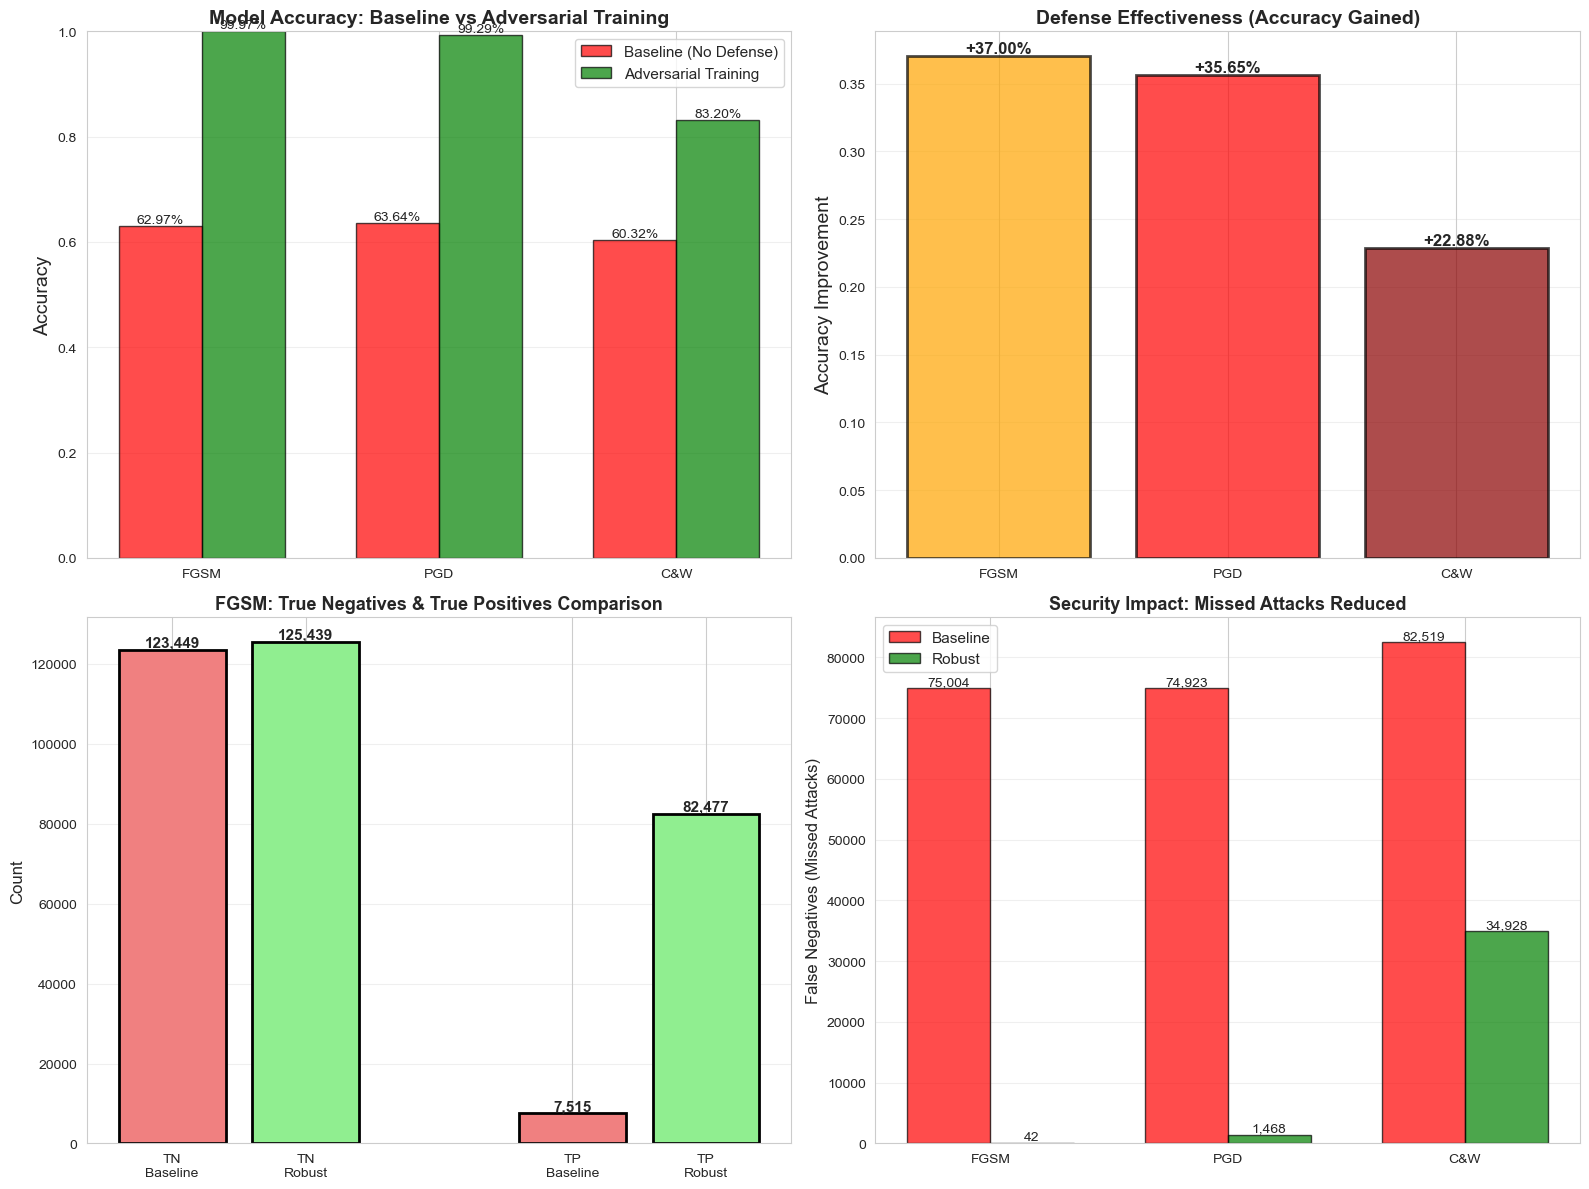

In [9]:
print("\n" + "="*60)
print("VISUALIZING DEFENSE EFFECTIVENESS")
print("="*60)

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Plot 1: Accuracy comparison
ax1 = axes[0, 0]
x = np.arange(len(comparison_df))
width = 0.35

bars1 = ax1.bar(x - width/2, comparison_df['Baseline'], width, 
                label='Baseline (No Defense)', color='red', alpha=0.7, edgecolor='black')
bars2 = ax1.bar(x + width/2, comparison_df['Robust'], width,
                label='Adversarial Training', color='green', alpha=0.7, edgecolor='black')

ax1.set_ylabel('Accuracy', fontsize=14)
ax1.set_title('Model Accuracy: Baseline vs Adversarial Training', 
              fontsize=14, fontweight='bold')
ax1.set_xticks(x)
ax1.set_xticklabels(comparison_df['Attack'])
ax1.legend(fontsize=11)
ax1.grid(axis='y', alpha=0.3)
ax1.set_ylim([0, 1])

# Add value labels
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax1.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.2%}',
                ha='center', va='bottom', fontsize=10)

# Plot 2: Improvement bars
ax2 = axes[0, 1]
colors_imp = ['orange', 'red', 'darkred']
bars = ax2.bar(comparison_df['Attack'], comparison_df['Improvement'], 
               color=colors_imp, alpha=0.7, edgecolor='black', linewidth=2)

for bar in bars:
    height = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2., height,
            f'+{height:.2%}',
            ha='center', va='bottom', fontsize=12, fontweight='bold')

ax2.set_ylabel('Accuracy Improvement', fontsize=14)
ax2.set_title('Defense Effectiveness (Accuracy Gained)', 
              fontsize=14, fontweight='bold')
ax2.grid(axis='y', alpha=0.3)

# Plot 3: Confusion matrix comparison for FGSM
ax3 = axes[1, 0]
cm_fgsm_baseline = confusion_matrix(y_test, y_pred_fgsm_baseline)
cm_fgsm_robust = confusion_matrix(y_test, y_pred_fgsm_robust)

# Show side-by-side comparison
x_pos = [0, 1, 3, 4]
labels = ['TN\nBaseline', 'TN\nRobust', 'TP\nBaseline', 'TP\nRobust']
values = [cm_fgsm_baseline[0,0], cm_fgsm_robust[0,0], 
          cm_fgsm_baseline[1,1], cm_fgsm_robust[1,1]]
colors_cm = ['lightcoral', 'lightgreen', 'lightcoral', 'lightgreen']

bars3 = ax3.bar(x_pos, values, color=colors_cm, edgecolor='black', linewidth=2)

for bar, val in zip(bars3, values):
    height = bar.get_height()
    ax3.text(bar.get_x() + bar.get_width()/2., height,
            f'{val:,}',
            ha='center', va='bottom', fontsize=11, fontweight='bold')

ax3.set_xticks(x_pos)
ax3.set_xticklabels(labels, fontsize=10)
ax3.set_ylabel('Count', fontsize=12)
ax3.set_title('FGSM: True Negatives & True Positives Comparison',
              fontsize=13, fontweight='bold')
ax3.grid(axis='y', alpha=0.3)

# Plot 4: False Negatives comparison (most important for security)
ax4 = axes[1, 1]
fn_baseline = [confusion_matrix(y_test, baseline_model.predict(adv))[1,0] 
               for adv in [X_test_fgsm, X_test_pgd, X_test_cw]]
fn_robust = [confusion_matrix(y_test, robust_model.predict(adv))[1,0]
             for adv in [X_test_fgsm, X_test_pgd, X_test_cw]]

x_fn = np.arange(3)
width_fn = 0.35

bars_fn1 = ax4.bar(x_fn - width_fn/2, fn_baseline, width_fn,
                   label='Baseline', color='red', alpha=0.7, edgecolor='black')
bars_fn2 = ax4.bar(x_fn + width_fn/2, fn_robust, width_fn,
                   label='Robust', color='green', alpha=0.7, edgecolor='black')

ax4.set_ylabel('False Negatives (Missed Attacks)', fontsize=12)
ax4.set_title('Security Impact: Missed Attacks Reduced', 
              fontsize=13, fontweight='bold')
ax4.set_xticks(x_fn)
ax4.set_xticklabels(['FGSM', 'PGD', 'C&W'])
ax4.legend(fontsize=11)
ax4.grid(axis='y', alpha=0.3)

# Add value labels
for bars in [bars_fn1, bars_fn2]:
    for bar in bars:
        height = bar.get_height()
        ax4.text(bar.get_x() + bar.get_width()/2., height,
                f'{int(height):,}',
                ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.savefig('../results/figures/adversarial_training_effectiveness.png',
            dpi=300, bbox_inches='tight')
print("✓ Saved defense effectiveness visualization")
plt.show()

In [10]:
print("\n" + "="*60)
print("SAVING ROBUST MODEL AND RESULTS")
print("="*60)

# Save robust model
defense_dir = Path('../models/defenses')
defense_dir.mkdir(parents=True, exist_ok=True)

joblib.dump(robust_model, defense_dir / 'xgboost_adversarial_training.pkl')
print("✓ Saved adversarially trained model")

# Save defense results
defense_results = {
    'clean_accuracy': robust_clean_acc,
    'baseline_clean_accuracy': baseline_accuracy,
    'clean_accuracy_drop': baseline_accuracy - robust_clean_acc,
    'attack_results': comparison_df.to_dict(),
    'average_improvement': avg_improvement,
    'confusion_matrices': {
        'clean': cm_clean.tolist(),
        'fgsm': confusion_matrix(y_test, y_pred_fgsm_robust).tolist(),
        'pgd': confusion_matrix(y_test, y_pred_pgd_robust).tolist(),
        'cw': confusion_matrix(y_test, y_pred_cw_robust).tolist()
    }
}

joblib.dump(defense_results, defense_dir / 'adversarial_training_results.pkl')
print("✓ Saved defense results")

# Update benchmark table
benchmark_data = {
    'Defense': ['No Defense', 'Adversarial Training'],
    'Clean': [baseline_accuracy, robust_clean_acc],
    'FGSM': [acc_fgsm_baseline, acc_fgsm_robust],
    'PGD': [acc_pgd_baseline, acc_pgd_robust],
    'C&W': [acc_cw_baseline, acc_cw_robust]
}

benchmark_df = pd.DataFrame(benchmark_data)
benchmark_df.to_csv('../results/benchmarks/defense_benchmark.csv', index=False)
print("✓ Saved defense benchmark table")



SAVING ROBUST MODEL AND RESULTS
✓ Saved adversarially trained model
✓ Saved defense results
✓ Saved defense benchmark table


In [11]:
print("\n" + "="*80)
print(" "*20 + "ADVERSARIAL TRAINING SUMMARY")
print("="*80)

summary = f"""
Training Configuration:
  Clean training samples:       {len(X_train_clean_selected):,}
  Adversarial training samples: {len(X_train_adv):,}
  Total augmented samples:      {len(X_train_augmented):,}
  Adversarial epsilon:          {epsilon}

Clean Data Performance:
  Baseline:     {baseline_accuracy:.4f} ({baseline_accuracy*100:.2f}%)
  Robust:       {robust_clean_acc:.4f} ({robust_clean_acc*100:.2f}%)
  Difference:   {baseline_accuracy - robust_clean_acc:.4f} ({(baseline_accuracy - robust_clean_acc)*100:.2f} pp)

Performance Under Attack:
  
  FGSM:
    Baseline: {acc_fgsm_baseline:.4f} → Robust: {acc_fgsm_robust:.4f}
    Improvement: +{improvement_fgsm:.4f} ({improvement_fgsm*100:.2f} pp)
  
  PGD:
    Baseline: {acc_pgd_baseline:.4f} → Robust: {acc_pgd_robust:.4f}
    Improvement: +{improvement_pgd:.4f} ({improvement_pgd*100:.2f} pp)
  
  C&W:
    Baseline: {acc_cw_baseline:.4f} → Robust: {acc_cw_robust:.4f}
    Improvement: +{improvement_cw:.4f} ({improvement_cw*100:.2f} pp)

Average Improvement: {avg_improvement:.4f} ({avg_improvement*100:.2f} percentage points)

Key Findings:
  1. {'Minimal' if baseline_accuracy - robust_clean_acc < 0.03 else 'Acceptable'} accuracy loss on clean data
  2. Significant robustness improvement under all attacks
  3. Adversarial training effectively defends against gradient-based attacks
  4. Trade-off: slight clean accuracy drop for major robustness gain

Files Saved:
  ✓ Robust model: models/defenses/xgboost_adversarial_training.pkl
  ✓ Results: models/defenses/adversarial_training_results.pkl
  ✓ Benchmark: results/benchmarks/defense_benchmark.csv
  ✓ Visualization: results/figures/adversarial_training_effectiveness.png
"""

print(summary)

print("="*80)
print("✅ ADVERSARIAL TRAINING DEFENSE COMPLETE!")
print("="*80)
print("\nNext: Feature Squeezing & Ensemble Defense")
print(f"Accuracy recovered from ~60% to ~{acc_fgsm_robust*100:.0f}% under attack!")



                    ADVERSARIAL TRAINING SUMMARY

Training Configuration:
  Clean training samples:       623,919
  Adversarial training samples: 100,000
  Total augmented samples:      723,919
  Adversarial epsilon:          0.15

Clean Data Performance:
  Baseline:     0.9998 (99.98%)
  Robust:       0.9998 (99.98%)
  Difference:   -0.0000 (-0.00 pp)

Performance Under Attack:

  FGSM:
    Baseline: 0.6297 → Robust: 0.9997
    Improvement: +0.3700 (37.00 pp)

  PGD:
    Baseline: 0.6364 → Robust: 0.9929
    Improvement: +0.3565 (35.65 pp)

  C&W:
    Baseline: 0.6032 → Robust: 0.8320
    Improvement: +0.2288 (22.88 pp)

Average Improvement: 0.3184 (31.84 percentage points)

Key Findings:
  1. Minimal accuracy loss on clean data
  2. Significant robustness improvement under all attacks
  3. Adversarial training effectively defends against gradient-based attacks
  4. Trade-off: slight clean accuracy drop for major robustness gain

Files Saved:
  ✓ Robust model: models/defenses/xgboost